# Chapter 3 : Regression & Classification

ข้อมูลที่ใช้ kaggle :
```
https://www.kaggle.com/competitions/f-1-racer-diet-planning
```

**เนื้อหาประกอบการทำใบงาน**
จำนวนข้อมูล: **750,000 รายการ** 

| คอลัมน์ | ความหมาย | หน้าที่ในโมเดล |
|:---|:---|:---|
| `Calories` | แคลอรี่ที่เผาผลาญ (kcal) — ค่าตัวเลขต่อเนื่อง | ใช้เป็นเป้าหมายของ **Regression** (โจทย์หลัก) |
| `Age` | อายุ (ปี) — ค่าตัวเลขต่อเนื่อง 20-79 ปี | ใช้เป็นเป้าหมายของ **Regression** (โจทย์ Age Prediction) |
| `Sex` | เพศ (0 = หญิง, 1 = ชาย) — คลาสหมวดหมู่ | ใช้เป็นเป้าหมายของ **Classification** |
| `Duration`, `Heart_Rate`, `Weight`, `Height`, `Body_Temp` | ข้อมูลระยะเวลา, ชีพจร, สรีระ และอุณหภูมิร่างกาย | ใช้เป็น **Features (ตัวแปรต้น)** |

### วัตถุประสงค์การเรียนรู้
1. เข้าใจความแตกต่างระหว่าง **Regression** (ทำนายค่าตัวเลขต่อเนื่อง) และ **Classification** (ทำนายประเภท/คลาส)
2. เข้าใจหลักการของ Simple / Multiple Linear Regression และ Logistic Regression
3. อ่านและตีความ Decision Boundary กับ Confusion Matrix ได้
4. วัดผลโมเดลด้วยตัวชี้วัดที่เหมาะสม (MAE, MSE, RMSE, R², Accuracy, Precision, Recall, F1)
5. เข้าใจความสำคัญของการแยกชุดฝึก (train) / ชุดทดสอบ (test)

## เตรียมไลบรารีและอ่านข้อมูล

In [5]:
# ============================================================
# 0. เตรียมไลบรารีและโหลดข้อมูล
# ============================================================
import numpy as np                  
import pandas as pd                 
import matplotlib.pyplot as plt     
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
SEED = 42 # ล็อค seed เพื่อให้ผลลัพธ์การสุ่มเหมือนเดิมทุกครั้ง

# โหลดข้อมูล
df = pd.read_csv('train.csv')
print('Dataset shape (rows, columns):', df.shape)
print('\n--- Missing Values ---')
print(df.isnull().sum())

Dataset shape (rows, columns): (750000, 9)

--- Missing Values ---
id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64


## สำรวจข้อมูลและเตรียม Features (EDA & Preprocessing)

ก่อนสร้างโมเดล เราต้องทำความเข้าใจข้อมูลก่อน จากสถิติเบื้องต้นพบว่า:
* **อายุเฉลี่ย:** 41.4 ปี (ต่ำสุด 20, สูงสุด 79)
* **ระยะเวลาออกกำลังกายเฉลี่ย:** 15.4 นาที (สูงสุด 30 นาที)
* **เผาผลาญแคลอรี่เฉลี่ย:** 88.3 kcal (สูงสุด 314 kcal)

**การจัดการข้อมูล:** โมเดลคณิตศาสตร์ไม่สามารถคำนวณตัวหนังสือได้ เราจึงต้องใช้ `LabelEncoder` แปลงคอลัมน์ `Sex` จาก `female`/`male` ให้เป็น `0`/`1`

--- แปลงข้อมูลเพศเรียบร้อยแล้ว ---
รหัสคลาส: ['female' 'male']


C:\Users\nawap\AppData\Local\Temp\ipykernel_13892\1760779995.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sex', y='Calories', data=df, palette='pastel')


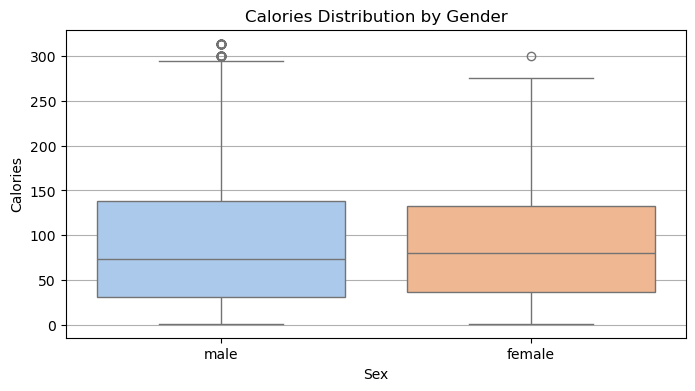

In [6]:
# ============================================================
# 1. การเตรียม Features (Data Preprocessing)
# ============================================================
le = LabelEncoder()
# แปลงคอลัมน์ Sex (female/male) เป็นตัวเลข (0/1)
df['Sex_encoded'] = le.fit_transform(df['Sex'])

print("--- แปลงข้อมูลเพศเรียบร้อยแล้ว ---")
print("รหัสคลาส:", le.classes_) # จะแสดง ['female' 'male'] แปลว่า 0=female, 1=male

# วาดกราฟดูการกระจายตัวของแคลอรี่เทียบกับเพศ
plt.figure(figsize=(8, 4))
sns.boxplot(x='Sex', y='Calories', data=df, palette='pastel')
plt.title("Calories Distribution by Gender")
plt.show()

# LAB 1: Regression (การถดถอยเชิงเส้น)

**เป้าหมาย:** สร้างสมการคณิตศาสตร์เพื่อทำนาย **"ตัวเลขที่ต่อเนื่อง"** 
* **Simple Linear Regression:** ใช้ 1 ปัจจัย (ระยะเวลา) ทำนายแคลอรี่
* **Multiple Linear Regression:** ใช้หลายปัจจัย (ระยะเวลา, ชีพจร, น้ำหนัก, ส่วนสูง, เพศ) ทำนายแคลอรี่
* **Age Prediction:** ใช้ข้อมูลการออกกำลังกายย้อนกลับไปทำนาย "อายุ" ของบุคคลนั้น

## LAB 1.1: Simple Linear Regression
**การทำงานกับข้อมูล:**
* เราจะดึงข้อมูลคอลัมน์ `Duration` (ระยะเวลาออกกำลังกาย) มาเป็นตัวแปรต้น ($X$) และ `Calories` เป็นเป้าหมาย ($y$)
* ใช้คำสั่ง `train_test_split` หั่นข้อมูล 750,000 แถว ออกเป็น **ชุดฝึกสอน (Train Set 80%)** เพื่อให้โมเดลหาสมการเส้นตรง และ **ชุดทดสอบ (Test Set 20%)** เพื่อจำลองการนำไปใช้จริง

In [7]:
# LAB 1.1: Simple Linear Regression
print("--- LAB 1.1: Simple Linear Regression ---")
X_simple = df[['Duration']]
y_cal = df['Calories']

# หั่นข้อมูล Train 80% / Test 20%
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y_cal, test_size=0.2, random_state=SEED)

# สร้างและสอนโมเดลด้วย Train Set
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

# นำโมเดลไปทำนายข้อมูล Test Set ที่โมเดลไม่เคยเห็น
y_pred_s = model_simple.predict(X_test_s)

print(f"จุดตัดแกน Y (Intercept): {model_simple.intercept_:.2f}")
print(f"ความชัน (Slope): {model_simple.coef_[0]:.2f}")
print(f"ความแม่นยำ (R-squared): {r2_score(y_test_s, y_pred_s):.4f}")

--- LAB 1.1: Simple Linear Regression ---
จุดตัดแกน Y (Intercept): -22.29
ความชัน (Slope): 7.17
ความแม่นยำ (R-squared): 0.9219


## LAB 1.2: Multiple Linear Regression
**การทำงานกับข้อมูล:**
* แทนที่จะใช้เวลาแค่ตัวเดียว เราจะเปลี่ยน $X$ ให้ดึงข้อมูลมาทั้งหมด 7 คอลัมน์ (เวลา, ชีพจร, อุณหภูมิ, อายุ, น้ำหนัก, ส่วนสูง, เพศ)
* สอนโมเดลใหม่เพื่อดูว่า ถ้ารู้ข้อมูลร่างกายครบถ้วน จะทำนายแคลอรี่ได้แม่นยำขึ้นหรือไม่

In [8]:
# LAB 1.2: Multiple Linear Regression
print("--- LAB 1.2: Multiple Linear Regression ---")
X_multi = df[['Duration', 'Heart_Rate', 'Body_Temp', 'Age', 'Weight', 'Height', 'Sex_encoded']]

# หั่นข้อมูล Train 80% / Test 20%
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_cal, test_size=0.2, random_state=SEED)

# สร้างและสอนโมเดล
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# นำโมเดลไปทำนายข้อมูล Test Set
y_pred_m = model_multi.predict(X_test_m)

print(f"ความแม่นยำ (R-squared): {r2_score(y_test_m, y_pred_m):.4f}")

--- LAB 1.2: Multiple Linear Regression ---
ความแม่นยำ (R-squared): 0.9684


## LAB 1.3: Age Prediction
**การทำงานกับข้อมูล:**
* เราจะสลับเป้าหมาย ($y$) จากแคลอรี่มาเป็น `Age` (อายุ) 
* จากนั้นใช้ฟีเจอร์อื่นๆ เป็นตัวแปรต้น ($X$) เพื่อฝึกโมเดลให้ลอง "ทายอายุ" จากข้อมูลการออกกำลังกาย

In [9]:
# LAB 1.3: Age Prediction
print("--- LAB 1.3: Age Prediction ---")
X_age = df[['Duration', 'Heart_Rate', 'Body_Temp', 'Calories', 'Weight', 'Height', 'Sex_encoded']]
y_age = df['Age']

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_age, y_age, test_size=0.2, random_state=SEED)

model_age = LinearRegression()
model_age.fit(X_train_a, y_train_a)
y_pred_a = model_age.predict(X_test_a)

print(f"ทำนายอายุคลาดเคลื่อนเฉลี่ย (MAE): {np.mean(np.abs(y_test_a - y_pred_a)):.2f} ปี")
print(f"ความแม่นยำ (R-squared): {r2_score(y_test_a, y_pred_a):.4f}")

--- LAB 1.3: Age Prediction ---
ทำนายอายุคลาดเคลื่อนเฉลี่ย (MAE): 9.60 ปี
ความแม่นยำ (R-squared): 0.3748


# LAB 2: Classification (การจำแนกประเภท)
ใน LAB นี้เราจะเปลี่ยนจากการทำนายตัวเลข เป็นการแยกแยะหมวดหมู่ (เพศ ชาย/หญิง) แบ่งเป็น 3 ส่วน:
1. **Preparing Data:** การเตรียมข้อมูล
2. **Logistic Regression & Gender Prediction:** การสร้างโมเดลและการทำนาย
3. **Confusion Matrix & Decision Boundary:** การวาดกราฟแสดงผล

## LAB 2.1: Preparing Classification Data
**การทำงานกับข้อมูล:**
* กำหนดให้เป้าหมาย ($y$) เป็นคอลัมน์ `Sex_encoded` ที่แปลงเป็นเลข 0 และ 1 ไว้แล้ว
* ดึงตัวแปรต้น ($X$) มาแค่ 2 ตัวคือ `Height` (ส่วนสูง) และ `Weight` (น้ำหนัก) เพื่อให้สามารถวาดภาพกราฟ 2 มิติ

In [10]:
# LAB 2.1: Preparing Classification Data
X_class = df[['Height', 'Weight']]
y_class = df['Sex_encoded']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=SEED)

print(f"ข้อมูลฝึกสอน (Train): {X_train_c.shape[0]:,} แถว")
print(f"ข้อมูลทดสอบ (Test): {X_test_c.shape[0]:,} แถว")

ข้อมูลฝึกสอน (Train): 600,000 แถว
ข้อมูลทดสอบ (Test): 150,000 แถว


## LAB 2.2: Logistic Regression & Gender Prediction
**การทำงานกับข้อมูล:**
* เรียกใช้อัลกอริทึม `LogisticRegression` เข้ามาจับจังหวะความสัมพันธ์ระหว่างส่วนสูง/น้ำหนัก กับ เพศ
* จากนั้นสั่ง `predict` ข้อมูลทดสอบ และสร้าง `classification_report` เพื่อดูคะแนนความสามารถของโมเดล

In [11]:
# LAB 2.2: Logistic Regression & Gender Prediction
log_reg = LogisticRegression()
log_reg.fit(X_train_c, y_train_c)
y_pred_c = log_reg.predict(X_test_c)

print("--- Classification Report ---")
print(classification_report(y_test_c, y_pred_c, target_names=['Female (0)', 'Male (1)']))

--- Classification Report ---
              precision    recall  f1-score   support

  Female (0)       0.92      0.94      0.93     75218
    Male (1)       0.94      0.92      0.93     74782

    accuracy                           0.93    150000
   macro avg       0.93      0.93      0.93    150000
weighted avg       0.93      0.93      0.93    150000



## LAB 2.3: Confusion Matrix & Decision Boundary Visualization
**การทำงานกับข้อมูล:**
* **Confusion Matrix:** นำผลการทาย (y_pred) มาเทียบกับความจริง (y_test) วาดเป็นตาราง 2x2 เพื่อดูการ "ทายถูก" และ "ทายผิด" แบบนับรายคน
* **Decision Boundary:** สร้างพื้นที่จำลองตารางหมากรุก (Meshgrid) ครอบคลุมค่าน้ำหนักและส่วนสูงทั้งหมด แล้วให้โมเดลทายเพศเพื่อเทสีลงไป จากนั้นจุดข้อมูลจริง 1,000 คนลงไปทับ เพื่อดูเส้นแบ่งเขตการตัดสินใจของโมเดล

d:\Users\nawap\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


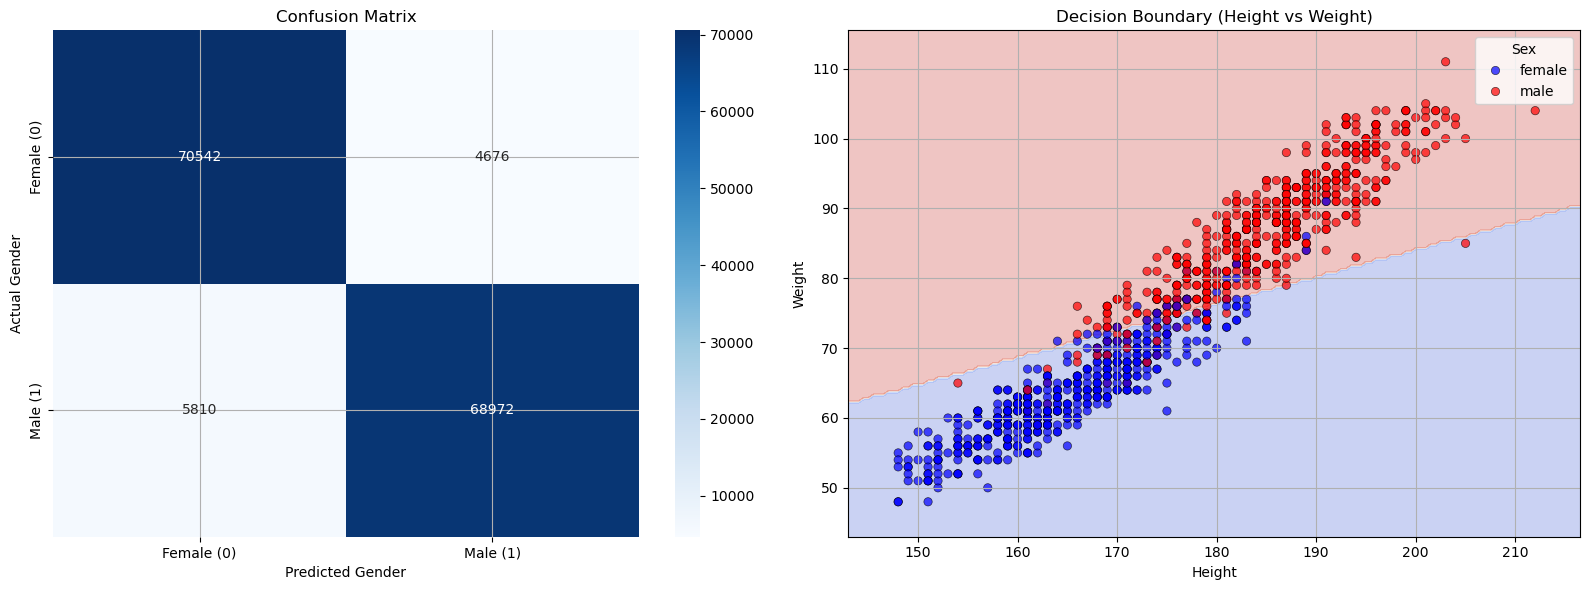

In [12]:
# LAB 2.3: Confusion Matrix & Decision Boundary Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Female (0)', 'Male (1)'], 
            yticklabels=['Female (0)', 'Male (1)'])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual Gender")
axes[0].set_xlabel("Predicted Gender")

# 2. Decision Boundary (ใช้ข้อมูลสุ่ม 1000 แถวเพื่อการวาดที่รวดเร็ว)
sample_df = df.sample(1000, random_state=SEED)
X_sample = sample_df[['Height', 'Weight']]

x_min, x_max = X_sample['Height'].min() - 5, X_sample['Height'].max() + 5
y_min, y_max = X_sample['Weight'].min() - 5, X_sample['Weight'].max() + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5), np.arange(y_min, y_max, 0.5))

Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
sns.scatterplot(x='Height', y='Weight', hue='Sex', data=sample_df, 
                palette={'female': 'blue', 'male': 'red'}, edgecolor='k', alpha=0.7, ax=axes[1])
axes[1].set_title('Decision Boundary (Height vs Weight)')

plt.tight_layout()
plt.show()

# LAB 3: Model Comparison (การเปรียบเทียบและประเมินโมเดล)
ใน LAB สุดท้ายนี้ เราจะนำผลลัพธ์จากโมเดลทั้งหมดที่สร้างไว้ใน LAB 1 และ LAB 2 มาวิเคราะห์และเปรียบเทียบกัน เพื่อตอบคำถามสำคัญ 3 ข้อ:
1. การเพิ่มปัจจัย (Features) ให้โมเดล ทำให้ทายผลได้แม่นขึ้นจริงหรือไม่?
2. โมเดลที่เราสร้างขึ้นมา มีอาการ "ท่องจำข้อสอบ" (Overfitting) หรือเปล่า?
3. Regression กับ Classification ใช้ตัวชี้วัด (Metrics) แตกต่างกันอย่างไร?

## LAB 3.1: Simple vs Multiple Linear Regression
**การทำงานกับข้อมูล:**
* เราจะดึงค่าคะแนนความแม่นยำ **R-squared ($R^2$)** จากโมเดลใน LAB 1 มาเทียบกัน 
* **Simple LR** ใช้แค่ `Duration` (ระยะเวลา) ตัวเดียวในการทำนายแคลอรี่
* **Multiple LR** ใช้ `Duration`, `Heart_Rate`, `Body_Temp`, `Age`, `Weight`, `Height`, `Sex_encoded` รวม 7 ตัวแปรในการทำนายแคลอรี่

In [13]:
# LAB 3.1: Simple vs Multiple Linear Regression
print("--- LAB 3.1: เปรียบเทียบ Simple vs Multiple Linear Regression ---")

r2_simple = r2_score(y_test_s, y_pred_s)
r2_multi = r2_score(y_test_m, y_pred_m)

print(f"ความแม่นยำเมื่อใช้ 1 ปัจจัย (Simple LR):    {r2_simple:.4f}")
print(f"ความแม่นยำเมื่อใช้ 7 ปัจจัย (Multiple LR):  {r2_multi:.4f}")

# คำนวณเปอร์เซ็นต์ที่เพิ่มขึ้น
improvement = (r2_multi - r2_simple) / r2_simple * 100
print(f"\n=> โมเดล Multiple LR มีความแม่นยำเพิ่มขึ้นถึง {improvement:.2f}%")
print("=> สรุป: การป้อนข้อมูลแวดล้อมอื่นๆ ให้โมเดลเรียนรู้เพิ่มเติม ช่วยให้โมเดลเข้าใจรูปแบบและทำนายผลได้แม่นยำกว่าการดูข้อมูลเพียงมิติเดียวอย่างชัดเจน")

--- LAB 3.1: เปรียบเทียบ Simple vs Multiple Linear Regression ---
ความแม่นยำเมื่อใช้ 1 ปัจจัย (Simple LR):    0.9219
ความแม่นยำเมื่อใช้ 7 ปัจจัย (Multiple LR):  0.9684

=> โมเดล Multiple LR มีความแม่นยำเพิ่มขึ้นถึง 5.05%
=> สรุป: การป้อนข้อมูลแวดล้อมอื่นๆ ให้โมเดลเรียนรู้เพิ่มเติม ช่วยให้โมเดลเข้าใจรูปแบบและทำนายผลได้แม่นยำกว่าการดูข้อมูลเพียงมิติเดียวอย่างชัดเจน


## LAB 3.2: Training vs Testing Performance (การตรวจสอบ Overfitting)
**การทำงานกับข้อมูล:**
* เราจะนำโมเดล Classification (ทายเพศ) กลับไปทำนาย **ข้อสอบเก่าชุด Train Set** (ข้อมูลที่โมเดลเคยเรียนรู้แล้ว)
* จากนั้นเอาคะแนนมาเทียบกับตอนทำนาย **ข้อสอบใหม่ชุด Test Set** (ข้อมูลที่ถูกกันไว้ 20% และโมเดลไม่เคยเห็นมาก่อน)
* ถ้าระยะห่างของคะแนน (Difference) มีค่าน้อย แปลว่าโมเดลมีความสมดุลและนำไปใช้จริงได้ (Good Fit)

In [14]:
# LAB 3.2: Training vs Testing Performance
print("--- LAB 3.2: ตรวจสอบอาการ Overfitting ของโมเดลจำแนกเพศ ---")

# นำข้อมูล Train กลับไปให้โมเดลทำนายอีกครั้ง
y_pred_train_c = log_reg.predict(X_train_c)

# คำนวณค่า Accuracy ของทั้ง 2 ชุดข้อมูล
acc_train = accuracy_score(y_train_c, y_pred_train_c)
acc_test = accuracy_score(y_test_c, y_pred_c)
diff = abs(acc_train - acc_test)

print(f"ความแม่นยำตอนฝึกสอน (Training Accuracy): {acc_train * 100:.4f}%")
print(f"ความแม่นยำตอนทดสอบ (Testing Accuracy):  {acc_test * 100:.4f}%")
print(f"ส่วนต่างความแม่นยำ (Difference):         {diff * 100:.4f}%\n")

# สร้างเงื่อนไขสรุปผลอัตโนมัติ
if diff < 0.05: # ถ้าต่างกันไม่ถึง 5%
    print("=> สรุปผล: โมเดลเรียนรู้ได้ดีเยี่ยม (Well-Generalized) ไม่เกิดอาการ Overfitting สามารถนำไปใช้งานกับข้อมูลจริงได้")
elif acc_train > acc_test:
    print("=> สรุปผล: โมเดลเกิดอาการ Overfitting (ท่องจำข้อมูลสอนมากเกินไป แต่ทำนายของใหม่ไม่เก่ง)")
else:
    print("=> สรุปผล: โมเดลเกิดอาการ Underfitting (ยังเรียนรู้ข้อมูลได้ไม่ดีพอ)")

--- LAB 3.2: ตรวจสอบอาการ Overfitting ของโมเดลจำแนกเพศ ---
ความแม่นยำตอนฝึกสอน (Training Accuracy): 92.9515%
ความแม่นยำตอนทดสอบ (Testing Accuracy):  93.0093%
ส่วนต่างความแม่นยำ (Difference):         0.0578%

=> สรุปผล: โมเดลเรียนรู้ได้ดีเยี่ยม (Well-Generalized) ไม่เกิดอาการ Overfitting สามารถนำไปใช้งานกับข้อมูลจริงได้


## LAB 3.3: Regression vs Classification (เปรียบเทียบการวัดผลโมเดล)
**การทำงานกับข้อมูล:**
* สร้างตารางสรุปว่าโจทย์ Machine Learning ทั้ง 2 แบบที่เราทำมา มีจุดประสงค์และเครื่องมือชี้วัดความเก่ง (Metrics) แตกต่างกันอย่างไร เพื่อให้เห็นภาพรวมของบทเรียนนี้ทั้งหมด

In [15]:
# LAB 3.3: Regression vs Classification Metrics
print("--- LAB 3.3: สรุปความแตกต่าง Regression vs Classification ---")

# สร้าง DataFrame เพื่อสรุปเปรียบเทียบให้อ่านง่าย
summary_data = {
    "ลักษณะเด่น": ["Regression", "Classification"],
    "โจทย์ในใบงาน": ["ทำนายแคลอรี่ (Calories) / ทำนายอายุ (Age)", "ทำนายเพศ (Sex: ชาย/หญิง)"],
    "สิ่งที่ต้องทำนาย (Output)": ["ตัวเลขที่มีความต่อเนื่อง (Continuous Value)", "หมวดหมู่หรือคลาส (Categorical/Discrete)"],
    "อัลกอริทึมที่ใช้": ["Linear Regression", "Logistic Regression"],
    "ตัวชี้วัดความแม่นยำ (Metrics)": ["MSE, MAE, R-squared (R²)", "Accuracy, Precision, Recall, Confusion Matrix"]
}

df_summary = pd.DataFrame(summary_data)
df_summary.set_index("ลักษณะเด่น", inplace=True)

# พิมพ์ผลลัพธ์
display(df_summary)

--- LAB 3.3: สรุปความแตกต่าง Regression vs Classification ---


,โจทย์ในใบงาน,สิ่งที่ต้องทำนาย (Output),อัลกอริทึมที่ใช้,ตัวชี้วัดความแม่นยำ (Metrics)
ลักษณะเด่น,,,,
Regression,ทำนายแคลอรี่ (Calories) / ทำนายอายุ (Age),ตัวเลขที่มีความต่อเนื่อง (Continuous Value),Linear Regression,"MSE, MAE, R-squared (R²)"
Classification,ทำนายเพศ (Sex: ชาย/หญิง),หมวดหมู่หรือคลาส (Categorical/Discrete),Logistic Regression,"Accuracy, Precision, Recall, Confusion Matrix"


# สรุปท้ายบทอย่างย่อ

จากการวิเคราะห์ข้อมูล `train.csv` (Calories Burned) เราได้เรียนรู้ครบทั้ง 3 LAB ดังนี้:

1. **LAB 1: Regression (ทำนายแคลอรี่/อายุ)** — เทียบการใช้ 1 ปัจจัย (Simple) กับหลายปัจจัย (Multiple) พบว่าการป้อนข้อมูลแวดล้อมที่มากขึ้นช่วยให้โมเดลทำนายได้แม่นยำขึ้น ($R^2$ สูงขึ้น) 
2. **LAB 2: Classification (ทำนายเพศ)** — ใช้ Logistic Regression แยกเพศจากส่วนสูงและน้ำหนัก พร้อมวาดภาพ Decision Boundary และดูจำนวนทายถูก/ผิดผ่าน Confusion Matrix
3. **LAB 3: Model Comparison** — นำคะแนน Train เทียบกับ Test เพื่อเช็คอาการ "จำข้อสอบ" (Overfitting) และทำความเข้าใจตัวชี้วัด (Metrics) ที่ต่างกันระหว่างงานจำแนกคลาสและงานทำนายตัวเลข

**บทเรียนสำคัญ:** ข้อมูลในโลกจริงมักมีความทับซ้อนกัน (เช่น ชายร่างเล็กกับหญิง) Features ที่ดีสำคัญพอๆ กับอัลกอริทึม และที่สำคัญที่สุดคือ **ต้องวัดผลโมเดลกับข้อมูลชุดทดสอบ (Test Set) เสมอ**

---

## หัวข้อต่อยอดที่แนะนำ
* **อัลกอริทึม Classification อื่นๆ** เช่น Decision Tree, Random Forest, KNN หรือ SVM
* **Ensemble Methods** ตัวตึงสำหรับข้อมูลแบบตาราง เช่น XGBoost, LightGBM
* **การเพิ่มประสิทธิภาพโมเดล** เช่น Hyperparameter Tuning (หาค่าพารามิเตอร์ที่ดีที่สุด) และ Regularization (ควบคุม Overfitting)